## Strategy 02: Oversampling by Minority Class Duplication
Naive oversampling to solve dataset unbalance, but probably better than the baseline.

In [1]:
import sys
import os
import json
from collections import Counter

from datasets import concatenate_datasets
from transformers import AutoTokenizer

# Local imports
sys.path.append(os.path.abspath(".."))

from src.config import DATASETS, MODEL_NAME, SEED, TRAIN_RATIO
from src.data_utils import get_tokenized_dataset
from src.paths import DATA_DIR, MODELS_DIR
from src.plot_utils import plot_metrics, results_to_dataframe

/home/phmgc/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Strategy Implementation (Minority Duplication)

In [2]:
def duplicate_minority_class(train_ds, seed=SEED):
    ds = train_ds.with_format(None)
    labels = [int(x) for x in ds["labels"]]
    class_counts = Counter(labels)

    if len(class_counts) < 2:
        return ds, class_counts, class_counts

    minority_label = min(class_counts, key=class_counts.get)
    majority_count = max(class_counts.values())
    minority_count = class_counts[minority_label]
    needed = majority_count - minority_count

    if needed <= 0:
        return ds, class_counts, class_counts

    minority_ds = ds.filter(lambda ex: int(ex["labels"]) == minority_label)
    full_copies, remainder = divmod(needed, len(minority_ds))

    parts = [ds] + [minority_ds] * full_copies
    if remainder > 0:
        parts.append(minority_ds.select(range(remainder)))

    oversampled = concatenate_datasets(parts).shuffle(seed=seed)
    new_counts = Counter(int(x) for x in oversampled["labels"])
    return oversampled, class_counts, new_counts

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

for author, dataset_names in DATASETS.items():
    for dataset_name in dataset_names:
        output_path = DATA_DIR / "tokenized" / "simple_oversampling" / author / dataset_name / "train"
        if output_path.exists():
            print(f"skipping {author}/{dataset_name} (already exists)")
            continue
        
        baseline_train = get_tokenized_dataset(
            author,
            dataset_name,
            tokenizer,
            split="train",
            strategy="baseline",
            train_ratio=TRAIN_RATIO,
            seed=SEED,
        )

        oversampled_train, before_counts, after_counts = duplicate_minority_class(baseline_train, seed=SEED)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        oversampled_train.save_to_disk(str(output_path))

        print(f"{author}/{dataset_name}: {dict(before_counts)} -> {dict(after_counts)}")
        print(f"saved: {output_path}")

skipping ribeiro/sentistrength_myspace (already exists)
skipping mcauley/luxury_beauty (already exists)
skipping mcauley/cds_reviews (already exists)
skipping mcauley/digital_music (already exists)


If model isn't available on Hugging Face, make sure to run training and evaluation before running the following cells:
```bash
python scripts/train.py --strategy simple_oversampling
python scripts/eval.py --strategy simple_oversampling
```

## Results

In [10]:
import numpy as np
import pandas as pd

eval_results_file = MODELS_DIR / "simple_oversampling" / "eval_results.json"
if not eval_results_file.exists():
    raise FileNotFoundError(f"Evaluation results not found at {eval_results_file}.")

with open(eval_results_file, "r") as f:
    results = json.load(f)

baseline_eval_file = MODELS_DIR / "baseline" / "eval_results.json"
if not baseline_eval_file.exists():
    raise FileNotFoundError(f"Baseline evaluation results not found at {baseline_eval_file}.")

with open(baseline_eval_file, "r") as f:
    baseline_results = json.load(f)

def load_train_times(strategy):
    """Return {dataset: elapsed_seconds} for MEASURED entries only.
    Excludes estimated times to ensure data consistency.
    """
    path = MODELS_DIR / strategy / "train_results.json"
    if not path.exists():
        return {}
    with open(path) as f:
        data = json.load(f)
    return {
        r["job_id"].split("/")[1]: r["elapsed_seconds"]
        for r in data
        if r.get("success") and r.get("elapsed_source") == "measured"
    }

baseline_times     = load_train_times("baseline")
oversampling_times = load_train_times("simple_oversampling")

# Keep only datasets with MEASURED times in both baseline and oversampling
common_ds = sorted(set(baseline_times.keys()) & set(oversampling_times.keys()))

speedup = {
    ds: baseline_times[ds] / oversampling_times[ds]
    for ds in common_ds
}

timing_df = pd.DataFrame(
    {
        "baseline (s)":      [baseline_times[ds] for ds in common_ds],
        "oversampling (s)":  [oversampling_times[ds] for ds in common_ds],
        "speedup":           [round(speedup[ds], 3) for ds in common_ds],
    },
    index=pd.Index(common_ds, name="dataset"),
)

print(f"Only showing {len(common_ds)} dataset(s) with measured times in BOTH strategies:")
print(f"   {', '.join(common_ds)}\n")
print(f"Missing measured times for:")
all_baseline = set(baseline_times.keys()) | set(oversampling_times.keys())
missing = all_baseline - set(common_ds)
for ds in sorted(missing):
    bl = "✓ measured" if ds in baseline_times else "✗ estimated/missing"
    os = "✓ measured" if ds in oversampling_times else "✗ estimated/missing"
    print(f"   {ds:30} baseline: {bl:20} oversampling: {os}")

print("\n")
timing_df

Only showing 4 dataset(s) with measured times in BOTH strategies:
   cds_reviews, digital_music, luxury_beauty, sentistrength_myspace

Missing measured times for:




,baseline (s),oversampling (s),speedup
dataset,,,
cds_reviews,13196.8,37661.1,0.350
digital_music,1884.3,6757.1,0.279
luxury_beauty,462.9,840.9,0.550
sentistrength_myspace,34.0,42.8,0.794


In [11]:
results_to_dataframe(results).round(4)

,accuracy,macro_f1,tpr_class_0,tpr_class_1,tpr_gap,imbalance_ratio
dataset,,,,,,
digital_music,0.9841,0.8358,0.6866,0.9916,0.3050,39.6671
sentistrength_myspace,0.9281,0.8366,0.6250,0.9790,0.3540,5.3182
cds_reviews,0.9664,0.8811,0.8856,0.9722,0.0866,13.8353
luxury_beauty,0.9807,0.9401,0.8689,0.9919,0.1230,10.7271


## Comparison with Baseline

In [12]:
os_df = results_to_dataframe(results)[["macro_f1", "tpr_gap"]].round(4)
os_df.columns = pd.MultiIndex.from_tuples([("simple_oversampling", c) for c in os_df.columns])

bl_df = results_to_dataframe(baseline_results)[["macro_f1", "tpr_gap"]].round(4)
bl_df.columns = pd.MultiIndex.from_tuples([("baseline", c) for c in bl_df.columns])

comparison = bl_df.join(os_df, how="outer").sort_index()

# Filter to only datasets with measured timing data
if common_ds:
    comparison = comparison.loc[comparison.index.isin(common_ds)]
    print(f"Note: Showing only {len(common_ds)} dataset(s) with complete measured timing data\n")
else:
    print("No datasets have measured times in both baseline and oversampling yet\n")

comparison

Note: Showing only 4 dataset(s) with complete measured timing data



baseline         simple_oversampling        
                      macro_f1 tpr_gap            macro_f1 tpr_gap
dataset                                                           
cds_reviews             0.9130  0.1604              0.8811  0.0866
digital_music           0.8541  0.3753              0.8358  0.3050
luxury_beauty           0.9309  0.1849              0.9401  0.1230
sentistrength_myspace   0.8587  0.2637              0.8366  0.3540

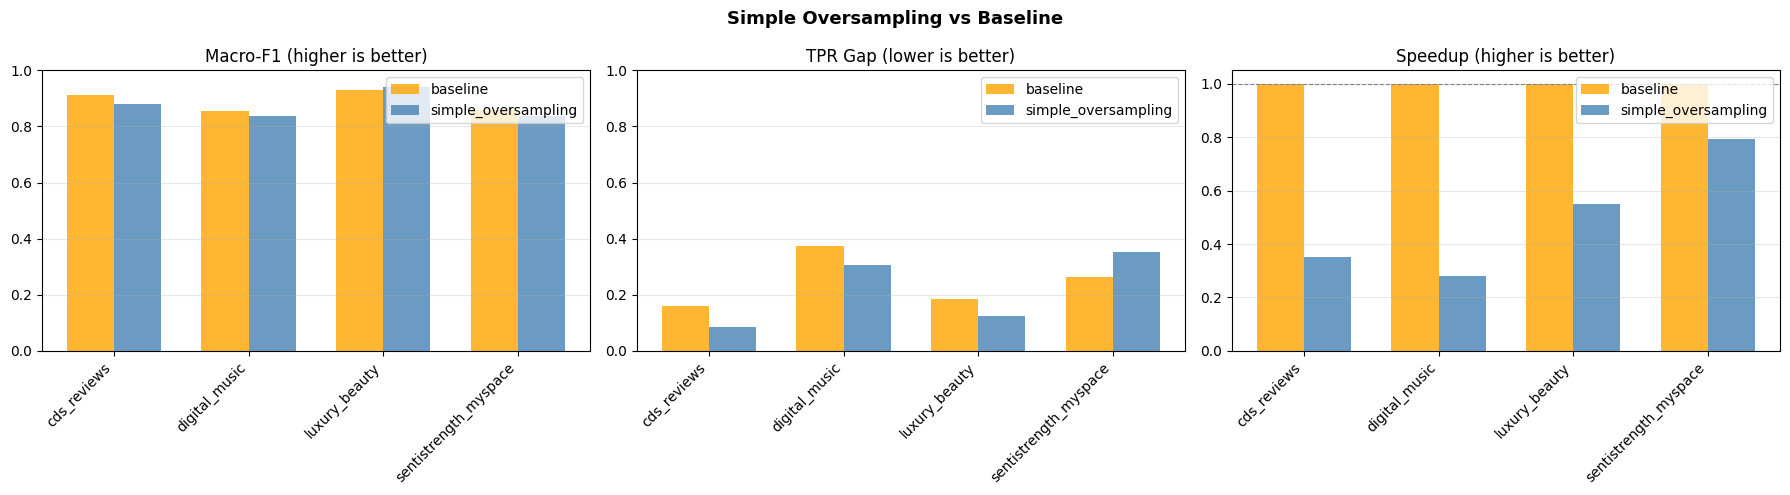

In [13]:
import matplotlib.pyplot as plt

# Only plot datasets with measured times in both strategies
datasets = common_ds if common_ds else []

if len(datasets) == 0:
    print("Cannot plot: No datasets have measured times in both strategies yet.")
    print("Run 'python scripts/train.py --strategy simple_oversampling' for missing datasets")
else:
    x = np.arange(len(datasets))
    width = 0.35

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Simple Oversampling vs Baseline", fontsize=13, fontweight="bold")

    for ax, metric, title in zip(
        axes,
        ["macro_f1", "tpr_gap"],
        ["Macro-F1 (higher is better)", "TPR Gap (lower is better)"],
    ):
        bl_vals = [baseline_results.get(ds, {}).get(metric, float("nan")) for ds in datasets]
        os_vals = [results.get(ds, {}).get(metric, float("nan")) for ds in datasets]

        ax.bar(x - width / 2, bl_vals, width, label="baseline", alpha=0.8, color="orange")
        ax.bar(x + width / 2, os_vals, width, label="simple_oversampling", alpha=0.8, color="steelblue")
        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=45, ha="right")
        ax.set_ylim(0, 1)
        ax.set_title(title)
        ax.legend()
        ax.grid(axis="y", alpha=0.3)

    sp_vals = [speedup.get(ds, float("nan")) for ds in datasets]
    axes[2].bar(x - width / 2, [1.0] * len(datasets), width, label="baseline", alpha=0.8, color="orange")
    axes[2].bar(x + width / 2, sp_vals, width, label="simple_oversampling", alpha=0.8, color="steelblue")
    axes[2].axhline(1, color="gray", linestyle="--", linewidth=0.8)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(datasets, rotation=45, ha="right")
    axes[2].set_title("Speedup (higher is better)")
    axes[2].legend()
    axes[2].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

## Conclusion

Simple oversampling by minority duplication **consistently reduces TPR Gap** across most datasets, showing that even a naive balancing strategy can improve model fairness. However, **Macro-F1 does not reliably improve** — for `cds_reviews`, `digital_music`, and `sentistrength_myspace`, Macro-F1 decreases compared to the baseline, suggesting the model overfits to the duplicated minority samples.

The **fairness-accuracy trade-off** observed here is: duplication reduces bias (lower TPR Gap) at the cost of slightly degraded overall classification performance (lower Macro-F1). This motivates the use of more sophisticated strategies, such as LLM paraphrasing (Strategy 04), which aims to introduce genuine lexical diversity rather than exact copies.